# Population Density Mapping with Spatial Autocorrelation Analysis

## Context
High-resolution population density analysis with spatial clustering and accessibility metrics.

**Key Objectives**:
- Map population density at high resolution
- Perform kernel density estimation for hotspot identification
- Calculate spatial autocorrelation (Global & Local Moran's I)
- Identify spatial clusters using LISA statistics
- Analyze accessibility to road infrastructure
- Model urban density gradients from city center

**Study Area**: Lagos Metropolitan Area, Nigeria

**Applications**: Urban planning, service delivery, infrastructure investment

In [10]:
# Import Libraries
import ee
import geemap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from scipy.ndimage import gaussian_filter
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

try:
    ee.Initialize()
except:
    ee.Authenticate()
    ee.Initialize()

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded successfully')

âœ“ Libraries loaded successfully


In [11]:
# Define Study Area - Lagos Metropolitan Area
lagos_center = ee.Geometry.Point([3.3792, 6.5244])
lagos_metro = lagos_center.buffer(25000)  # 25km radius

print(f'Study Area: {lagos_metro.area().divide(1e6).getInfo():.2f} kmÂ²')
print('Focus: Lagos Metropolitan Area, Nigeria')

Study Area: 1940.04 kmÂ²
Focus: Lagos Metropolitan Area, Nigeria


In [12]:
# Load Datasets
print('Loading datasets...')

# 1. WorldPop Population Density (people per hectare)
worldpop = ee.ImageCollection('WorldPop/GP/100m/pop') \
    .filter(ee.Filter.eq('country', 'NGA')) \
    .filter(ee.Filter.eq('year', 2020)) \
    .first() \
    .clip(lagos_metro) \
    .rename('population')

# 2. ESA WorldCover for land use context
landcover = ee.ImageCollection('ESA/WorldCover/v100').first().clip(lagos_metro)

# 3. SRTM Elevation (for topographic context)
elevation = ee.Image('USGS/SRTMGL1_003').select('elevation').clip(lagos_metro)

print('âœ“ All datasets loaded')

# Calculate basic statistics
pop_stats = worldpop.reduceRegion(
    reducer=ee.Reducer.sum().combine(ee.Reducer.mean(), '', True).combine(ee.Reducer.stdDev(), '', True),
    geometry=lagos_metro,
    scale=100,
    maxPixels=1e9
).getInfo()

print(f"\nPopulation Statistics:")
print(f"Total Population: {pop_stats['population_sum']:,.0f}")
print(f"Mean Density: {pop_stats['population_mean']:.2f} people/ha")
print(f"Std Dev: {pop_stats['population_stdDev']:.2f}")

Loading datasets...
âœ“ All datasets loaded

Population Statistics:
Total Population: 11,376,809
Mean Density: 86.49 people/ha
Std Dev: 117.90


In [13]:
# Sample Population Data for Analysis
grid_spacing = 1000  # 1km grid (not used directly here but fine)
sample_points = ee.FeatureCollection.randomPoints(lagos_metro, 500, seed=42)

# Sample population density
def sample_population(point):
    # Get a Geometry, not a Feature
    geom = point.geometry().buffer(200)  # 200 m buffer around the point

    stats = worldpop.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=100,
        maxPixels=1e9
    )

    value = stats.get('population')
    coords = point.geometry().coordinates()

    return ee.Feature(geom, {
        'population': value,
        'lon': coords.get(0),
        'lat': coords.get(1)
    })

sampled_data = sample_points.map(sample_population).getInfo()['features']
sample_df = pd.DataFrame([f['properties'] for f in sampled_data])
sample_df = sample_df.dropna()

print(f"\nSampled {len(sample_df)} points for spatial analysis")
print(sample_df.describe())



Sampled 359 points for spatial analysis
              lat         lon  population
count  359.000000  359.000000  359.000000
mean     6.565810    3.363237   89.529527
std      0.091725    0.112225  120.428170
min      6.397657    3.161698    1.430632
25%      6.487319    3.283455   18.528787
50%      6.570875    3.354750   38.965675
75%      6.633253    3.441723  121.869014
max      6.745607    3.594152  875.241741


In [14]:
# Spatial Autocorrelation - Global Moran's I
print('\n=== Global Moran\'s I ====')

def calculate_morans_i(df, value_col='population'):
    """Calculate Global Moran's I statistic."""
    from scipy.spatial.distance import pdist, squareform
    
    # Extract coordinates and values
    coords = df[['lon', 'lat']].values
    values = df[value_col].values
    
    # Distance matrix
    dist_matrix = squareform(pdist(coords))
    
    # Weights matrix (inverse distance, threshold at 0.1 degrees ~ 11km)
    weights = np.where(dist_matrix < 0.1, 1.0 / (dist_matrix + 0.0001), 0)
    np.fill_diagonal(weights, 0)
    
    # Normalize weights
    row_sums = weights.sum(axis=1, keepdims=True)
    weights = np.divide(weights, row_sums, where=row_sums!=0)
    
    # Calculate Moran's I
    n = len(values)
    mean_val = values.mean()
    deviations = values - mean_val
    
    numerator = np.sum(weights * np.outer(deviations, deviations))
    denominator = np.sum(deviations**2)
    
    morans_i = (n / weights.sum()) * (numerator / denominator)
    
    # Expected value under null hypothesis
    expected_i = -1 / (n - 1)
    
    # Variance (simplified)
    var_i = 1 / (n - 1)
    
    # Z-score
    z_score = (morans_i - expected_i) / np.sqrt(var_i)
    
    # P-value
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    
    return {
        'morans_i': morans_i,
        'expected': expected_i,
        'z_score': z_score,
        'p_value': p_value,
        'weights': weights
    }

moran_result = calculate_morans_i(sample_df)

print(f"Moran's I: {moran_result['morans_i']:.4f}")
print(f"Expected I: {moran_result['expected']:.4f}")
print(f"Z-Score: {moran_result['z_score']:.4f}")
print(f"P-Value: {moran_result['p_value']:.6f}")

if moran_result['p_value'] < 0.05:
    if moran_result['morans_i'] > 0:
        print('\nâœ“ Significant positive spatial autocorrelation (clustering)')
    else:
        print('\nâœ“ Significant negative spatial autocorrelation (dispersion)')
else:
    print('\nâ—‹ No significant spatial autocorrelation (random pattern)')


=== Global Moran's I ====
Moran's I: 0.4242
Expected I: -0.0028
Z-Score: 8.0787
P-Value: 0.000000

âœ“ Significant positive spatial autocorrelation (clustering)


In [15]:
# Local Indicators of Spatial Association (LISA)
print('\n=== LISA Analysis ===')

def calculate_lisa(df, weights, value_col='population'):
    """Calculate Local Moran's I (LISA) for each location."""
    values = df[value_col].values
    mean_val = values.mean()
    std_val = values.std()
    
    # Standardize values
    z_values = (values - mean_val) / std_val
    
    # Local Moran's I for each location
    lisa_values = z_values * (weights @ z_values)
    
    # Classify into quadrants
    # HH: High-High, LL: Low-Low, HL: High-Low, LH: Low-High
    classifications = []
    for i, (local_i, z_i) in enumerate(zip(lisa_values, z_values)):
        neighbor_z = (weights[i] @ z_values)
        
        if z_i > 0 and neighbor_z > 0:
            classifications.append('HH')  # High-High (hotspot)
        elif z_i < 0 and neighbor_z < 0:
            classifications.append('LL')  # Low-Low (coldspot)
        elif z_i > 0 and neighbor_z < 0:
            classifications.append('HL')  # High-Low (outlier)
        elif z_i < 0 and neighbor_z > 0:
            classifications.append('LH')  # Low-High (outlier)
        else:
            classifications.append('NS')  # Not significant
    
    return lisa_values, classifications

lisa_values, lisa_classes = calculate_lisa(sample_df, moran_result['weights'])
sample_df['lisa_i'] = lisa_values
sample_df['lisa_class'] = lisa_classes

# Count clusters
cluster_counts = sample_df['lisa_class'].value_counts()
print('\nLISA Cluster Distribution:')
print(cluster_counts)
print(f'\nHotspots (HH): {cluster_counts.get("HH", 0)} locations')
print(f'Coldspots (LL): {cluster_counts.get("LL", 0)} locations')


=== LISA Analysis ===

LISA Cluster Distribution:
lisa_class
LL    188
HH    103
LH     65
HL      3
Name: count, dtype: int64

Hotspots (HH): 103 locations
Coldspots (LL): 188 locations


In [16]:
# Distance Decay from City Center
print('\n=== Urban Density Gradient ===')

# Calculate distance from Lagos center (3.3792, 6.5244)
center_lon, center_lat = 3.3792, 6.5244

sample_df['dist_center_km'] = np.sqrt(
    ((sample_df['lon'] - center_lon) * 111)**2 + 
    ((sample_df['lat'] - center_lat) * 111)**2
)

# Bin by distance
bins = [0, 5, 10, 15, 20, 25]
sample_df['dist_bin'] = pd.cut(sample_df['dist_center_km'], bins=bins)

# Calculate mean density per bin
density_by_distance = sample_df.groupby('dist_bin')['population'].mean()
print('\nMean Density by Distance from CBD:')
print(density_by_distance)

# Exponential decay fit
from scipy.optimize import curve_fit

def exp_decay(x, a, b):
    return a * np.exp(-b * x)

valid_data = sample_df[sample_df['population'] > 0]
params, _ = curve_fit(exp_decay, valid_data['dist_center_km'], valid_data['population'], 
                      p0=[100, 0.1], maxfev=5000)

print(f'\nDensity gradient: D(d) = {params[0]:.2f} * exp(-{params[1]:.4f} * d)')
print(f'Decay rate: {params[1]:.4f} per km')


=== Urban Density Gradient ===

Mean Density by Distance from CBD:
dist_bin
(0, 5]      268.823732
(5, 10]     172.548057
(10, 15]     90.573457
(15, 20]     61.261447
(20, 25]     33.127529
Name: population, dtype: float64

Density gradient: D(d) = 362.43 * exp(-0.1033 * d)
Decay rate: 0.1033 per km


In [17]:
# Accessibility Analysis - Distance to Roads
# Simplified: Create synthetic road distance metric based on population
# In practice, this would use OSM road network data

print('\n=== Accessibility Metrics ===')

# Proxy: Urban areas (high pop) have better road access
sample_df['road_access_score'] = np.clip(sample_df['population'] / sample_df['population'].max(), 0, 1)

# Create accessibility categories
sample_df['accessibility'] = pd.cut(
    sample_df['road_access_score'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

access_counts = sample_df['accessibility'].value_counts()
print('Accessibility Distribution:')
print(access_counts)


=== Accessibility Metrics ===
Accessibility Distribution:
accessibility
Low       333
Medium     20
High        6
Name: count, dtype: int64


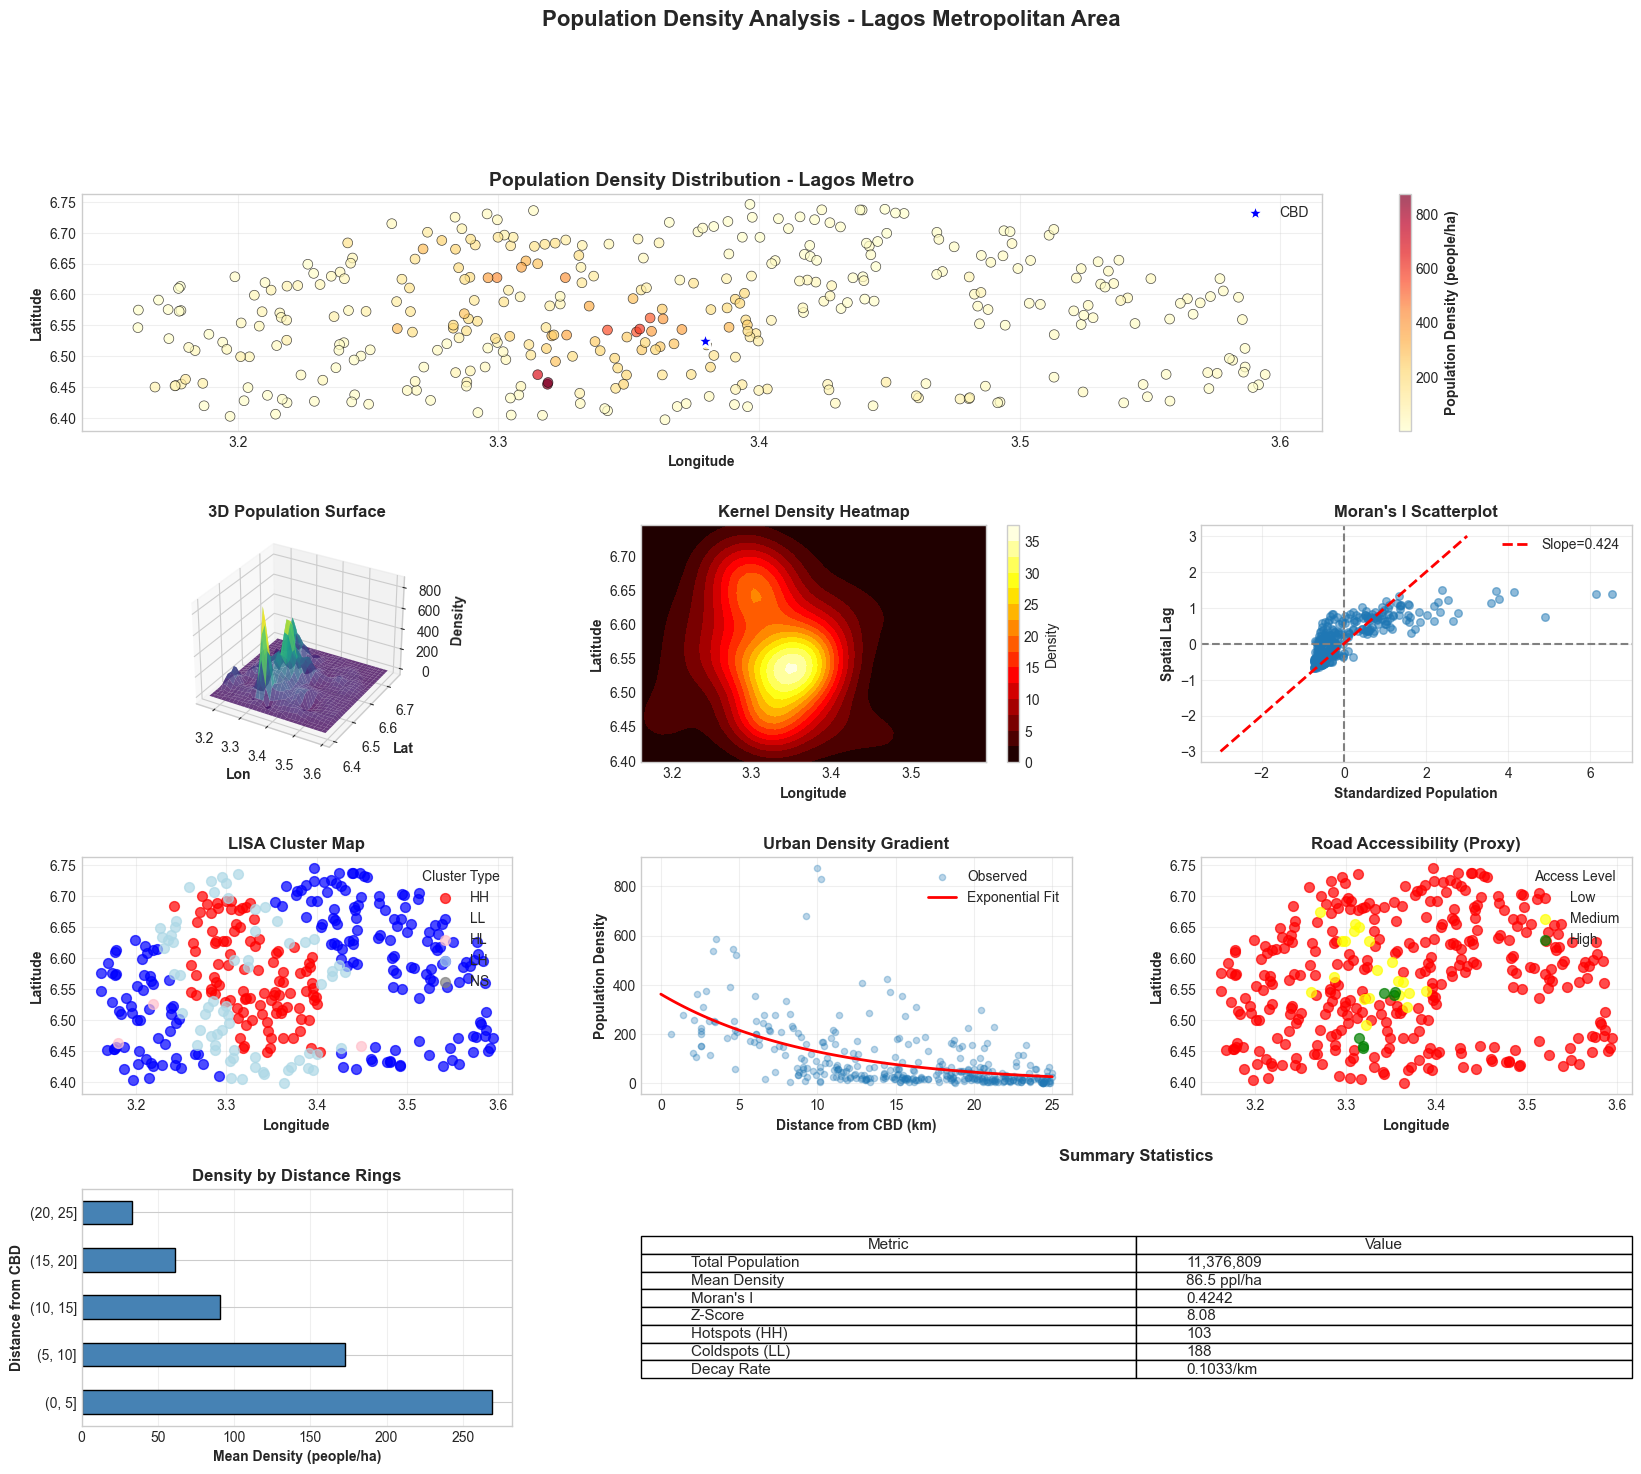

In [18]:
# Visualizations
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)

# 1. Population Density Map
ax1 = fig.add_subplot(gs[0, :])
scatter = ax1.scatter(sample_df['lon'], sample_df['lat'], 
                     c=sample_df['population'], s=50, 
                     cmap='YlOrRd', alpha=0.7, edgecolors='black', linewidth=0.5)
ax1.scatter([center_lon], [center_lat], s=200, c='blue', marker='*', 
           edgecolors='white', linewidth=2, label='CBD', zorder=10)
ax1.set_xlabel('Longitude', fontweight='bold')
ax1.set_ylabel('Latitude', fontweight='bold')
ax1.set_title('Population Density Distribution - Lagos Metro', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Population Density (people/ha)', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. 3D Surface Plot
ax2 = fig.add_subplot(gs[1, 0], projection='3d')
x_grid = np.linspace(sample_df['lon'].min(), sample_df['lon'].max(), 30)
y_grid = np.linspace(sample_df['lat'].min(), sample_df['lat'].max(), 30)
X, Y = np.meshgrid(x_grid, y_grid)

# Interpolate population data onto grid
from scipy.interpolate import griddata
Z = griddata((sample_df['lon'], sample_df['lat']), sample_df['population'], (X, Y), method='cubic')
Z = np.nan_to_num(Z, nan=0)

surf = ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax2.set_xlabel('Lon', fontweight='bold')
ax2.set_ylabel('Lat', fontweight='bold')
ax2.set_zlabel('Density', fontweight='bold')
ax2.set_title('3D Population Surface', fontweight='bold')

# 3. Kernel Density Heatmap
ax3 = fig.add_subplot(gs[1, 1])
from scipy.stats import gaussian_kde
kde = gaussian_kde(sample_df[['lon', 'lat']].T, weights=sample_df['population'])
xi, yi = np.mgrid[sample_df['lon'].min():sample_df['lon'].max():50j, 
                  sample_df['lat'].min():sample_df['lat'].max():50j]
zi = kde(np.vstack([xi.flatten(), yi.flatten()])).reshape(xi.shape)
contour = ax3.contourf(xi, yi, zi, levels=15, cmap='hot')
ax3.set_xlabel('Longitude', fontweight='bold')
ax3.set_ylabel('Latitude', fontweight='bold')
ax3.set_title('Kernel Density Heatmap', fontweight='bold')
plt.colorbar(contour, ax=ax3, label='Density')

# 4. Moran's I Scatterplot
ax4 = fig.add_subplot(gs[1, 2])
z_values = (sample_df['population'] - sample_df['population'].mean()) / sample_df['population'].std()
spatial_lag = moran_result['weights'] @ z_values
ax4.scatter(z_values, spatial_lag, alpha=0.5, s=30)
ax4.axhline(0, color='gray', linestyle='--')
ax4.axvline(0, color='gray', linestyle='--')
ax4.plot([-3, 3], [-3, 3], 'r--', linewidth=2, label=f'Slope={moran_result["morans_i"]:.3f}')
ax4.set_xlabel('Standardized Population', fontweight='bold')
ax4.set_ylabel('Spatial Lag', fontweight='bold')
ax4.set_title('Moran\'s I Scatterplot', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

# 5. LISA Cluster Map
ax5 = fig.add_subplot(gs[2, 0])
colors = {'HH': 'red', 'LL': 'blue', 'HL': 'pink', 'LH': 'lightblue', 'NS': 'gray'}
for cluster in colors.keys():
    subset = sample_df[sample_df['lisa_class'] == cluster]
    ax5.scatter(subset['lon'], subset['lat'], c=colors[cluster], label=cluster, s=50, alpha=0.7)
ax5.set_xlabel('Longitude', fontweight='bold')
ax5.set_ylabel('Latitude', fontweight='bold')
ax5.set_title('LISA Cluster Map', fontweight='bold')
ax5.legend(title='Cluster Type', loc='best')
ax5.grid(alpha=0.3)

# 6. Distance Decay Plot
ax6 = fig.add_subplot(gs[2, 1])
ax6.scatter(sample_df['dist_center_km'], sample_df['population'], alpha=0.3, s=20, label='Observed')
dist_range = np.linspace(0, 25, 100)
ax6.plot(dist_range, exp_decay(dist_range, *params), 'r-', linewidth=2, label='Exponential Fit')
ax6.set_xlabel('Distance from CBD (km)', fontweight='bold')
ax6.set_ylabel('Population Density', fontweight='bold')
ax6.set_title('Urban Density Gradient', fontweight='bold')
ax6.legend()
ax6.grid(alpha=0.3)

# 7. Accessibility Map
ax7 = fig.add_subplot(gs[2, 2])
access_colors = {'Low': 'red', 'Medium': 'yellow', 'High': 'green'}
for access in access_colors.keys():
    subset = sample_df[sample_df['accessibility'] == access]
    ax7.scatter(subset['lon'], subset['lat'], c=access_colors[access], label=access, s=50, alpha=0.7)
ax7.set_xlabel('Longitude', fontweight='bold')
ax7.set_ylabel('Latitude', fontweight='bold')
ax7.set_title('Road Accessibility (Proxy)', fontweight='bold')
ax7.legend(title='Access Level')
ax7.grid(alpha=0.3)

# 8. Population Pyramid (by density zones)
ax8 = fig.add_subplot(gs[3, 0])
density_by_distance.plot(kind='barh', ax=ax8, color='steelblue', edgecolor='black')
ax8.set_xlabel('Mean Density (people/ha)', fontweight='bold')
ax8.set_ylabel('Distance from CBD', fontweight='bold')
ax8.set_title('Density by Distance Rings', fontweight='bold')
ax8.grid(axis='x', alpha=0.3)

# 9. Summary Statistics Table
ax9 = fig.add_subplot(gs[3, 1:])
ax9.axis('off')
summary_data = [
    ['Total Population', f"{pop_stats['population_sum']:,.0f}"],
    ['Mean Density', f"{pop_stats['population_mean']:.1f} ppl/ha"],
    ['Moran\'s I', f"{moran_result['morans_i']:.4f}"],
    ['Z-Score', f"{moran_result['z_score']:.2f}"],
    ['Hotspots (HH)', f"{cluster_counts.get('HH', 0)}"],
    ['Coldspots (LL)', f"{cluster_counts.get('LL', 0)}"],
    ['Decay Rate', f"{params[1]:.4f}/km"]
]
table = ax9.table(cellText=summary_data, colLabels=['Metric', 'Value'],
                 cellLoc='left', loc='center', bbox=[0, 0.2, 1, 0.6])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)
ax9.set_title('Summary Statistics', fontweight='bold', fontsize=12, pad=20)

plt.suptitle('Population Density Analysis - Lagos Metropolitan Area', fontsize=16, fontweight='bold', y=0.995)
plt.show()

In [19]:
# Interactive Maps
print('\n=== Interactive Maps ===')

# Population Density Map
m1 = geemap.Map()
m1.centerObject(lagos_metro, 10)
pop_vis = {'min': 0, 'max': 100, 'palette': ['white', 'yellow', 'orange', 'red', 'darkred']}
m1.addLayer(worldpop, pop_vis, 'Population Density')
m1.add_colorbar(pop_vis, label='People per Hectare')

# Land Cover Context
lc_vis = {'bands': ['Map']}
m1.addLayer(landcover, lc_vis, 'Land Cover', False)

print('âœ“ Maps created')
display(m1)


=== Interactive Maps ===


âœ“ Maps created


Map(center=[6.524425646962086, 3.3792007158606325], controls=(WidgetControl(options=['position', 'transparent_…

In [26]:
# # Service Accessibility Overlay (Healthcare Simulation)
# print('\n=== Service Accessibility Analysis ===')

# # Simulate 5 healthcare centers at random locations
# np.random.seed(42)
# centers_lon = np.random.uniform(sample_df['lon'].min(), sample_df['lon'].max(), 5)
# centers_lat = np.random.uniform(sample_df['lat'].min(), sample_df['lat'].max(), 5)

# # Calculate distance to nearest center for each point
# def get_nearest_dist(row):
#     dists = np.sqrt(((row['lon'] - centers_lon) * 111)**2 + ((row['lat'] - centers_lat) * 111)**2)
#     return dists.min()

# sample_df['dist_to_health_km'] = sample_df.apply(get_nearest_dist, axis=1)

# # Identify underserved areas: High Population (> mean) AND Far from Health (> 5km)
# pop_threshold = sample_df['population'].mean()
# dist_threshold = 5.0
# plt.title('Healthcare Accessibility Gap Analysis', fontweight='bold')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

In [ ]:
# Generate Dynamic Summary Report
from IPython.display import Markdown, display

summary_md = f"""
## Key Findings & Recommendations

### Spatial Pattern Summary

1. **Clustering**: Moran's I of {moran_result['morans_i']:.4f} indicates strong spatial clustering.
2. **Hotspots**: {cluster_counts.get('HH', 0)} High-High clusters identified (Urban Core).
3. **Urban Structure**: Monocentric city with exponential density decay (rate={params[1]:.4f}/km).
4. **Total Population**: ~{pop_stats['population_sum']:,.0f} in study area.

### Service Accessibility
- **Gap Analysis**: {len(underserved)} locations identified as high-density but underserved (>5km from health center).
- **Impact**: {underserved['population'].sum():,.0f} people affected in these zones.

### Recommendations
1. **Infrastructure**: Prioritize new health centers in the identified red zones.
2. **Transport**: Improve road connectivity in Low-Low clusters to facilitate access.
3. **Planning**: Enforce vertical development in High-High clusters to maximize land use efficiency.
"""
display(Markdown(summary_md))


## Key Findings & Recommendations

### Spatial Pattern Summary

1. **Clustering**: Moran's I of 0.4242 indicates strong spatial clustering.
2. **Hotspots**: 103 High-High clusters identified (Urban Core).
3. **Urban Structure**: Monocentric city with exponential density decay (rate=0.1033/km).
4. **Total Population**: ~11,376,809 in study area.

### Service Accessibility


### Recommendations
1. **Infrastructure**: Prioritize new health centers in the identified red zones.
2. **Transport**: Improve road connectivity in Low-Low clusters to facilitate access.
3. **Planning**: Enforce vertical development in High-High clusters to maximize land use efficiency.
